In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

In [ ]:
import idx2numpy
import numpy as np

# Load data
X_train = idx2numpy.convert_from_file('../dataset/train-images.idx3-ubyte')
y_train = idx2numpy.convert_from_file('../dataset/train-labels.idx1-ubyte')

X_test = idx2numpy.convert_from_file('../dataset/t10k-images.idx3-ubyte')
y_test = idx2numpy.convert_from_file('../dataset/t10k-labels.idx1-ubyte')

print(X_train.shape)  # (60000, 28, 28)
print(y_train.shape)  # (60000,)

(60000, 28, 28)
(60000,)


In [3]:
from tensorflow.keras.utils import to_categorical

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense

model = Sequential()

model.add(Conv2D(6, (5,5), activation='tanh', input_shape=(28,28,1)))
model.add(AveragePooling2D(pool_size=(2,2)))

model.add(Conv2D(16, (5,5), activation='tanh'))
model.add(AveragePooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(120, activation='tanh'))
model.add(Dense(84, activation='tanh'))

model.add(Dense(10, activation='softmax'))

c:\Masters\MTech 2nd Sem\ANN Assignment 2\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_test, y_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9359 - loss: 0.2120 - val_accuracy: 0.9611 - val_loss: 0.1341
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9661 - loss: 0.1114 - val_accuracy: 0.9730 - val_loss: 0.0875
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9761 - loss: 0.0781 - val_accuracy: 0.9793 - val_loss: 0.0676
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9816 - loss: 0.0593 - val_accuracy: 0.9805 - val_loss: 0.0613
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9854 - loss: 0.0481 - val_accuracy: 0.9848 - val_loss: 0.0499
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9880 - loss: 0.0400 - val_accuracy: 0.9847 - val_loss: 0.0480
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9891 - loss: 0.0348 - val_accuracy: 0.9847 - val_loss: 0.0498
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9909 - loss: 0.0293 - val_accura

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9875 - loss: 0.0357
Test Accuracy: 0.987500011920929


In [ ]:
model.save("../model/lenet_mnist.h5")

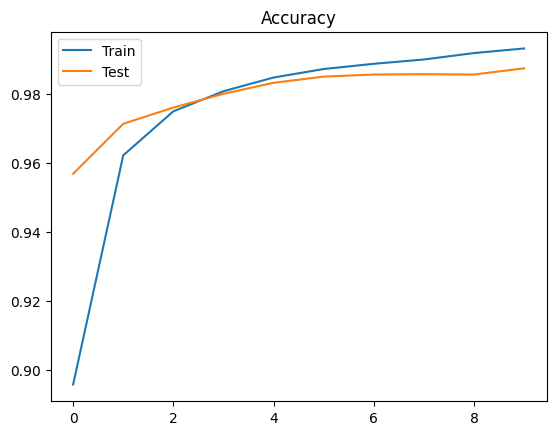

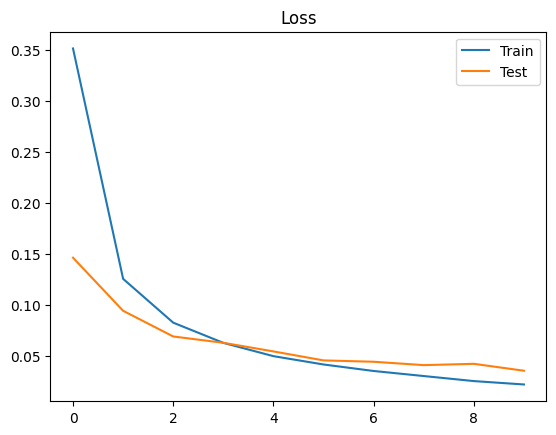

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(['Train', 'Test'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(['Train', 'Test'])
plt.show()

In [1]:
from PIL import Image
import numpy as np
from tensorflow.keras.models import load_model

model = load_model("../model/lenet_mnist.h5")

img = Image.open("../test_images/digit4.png").convert('L')  # grayscale
img = img.resize((28, 28))

img = np.array(img)
img = 255 - img   # invert if needed
img = img / 255.0

img = img.reshape(1, 28, 28, 1)

prediction = model.predict(img)
print("Predicted Digit:", np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
Predicted Digit: 8


In [ ]:
from PIL import Image
import numpy as np
import cv2
from tensorflow.keras.models import load_model

# Load model
model = load_model("../model/lenet_mnist.h5")

# Load image
img = Image.open("../test_images/digit2_2.png").convert('L')  # grayscale

# Convert to numpy
img = np.array(img)

# Resize to MNIST size
img = cv2.resize(img, (28, 28))

# Apply Gaussian Blur (remove noise)
img = cv2.GaussianBlur(img, (5, 5), 0)

# Threshold (remove background lines/noise)
_, img = cv2.threshold(img, 100, 255, cv2.THRESH_BINARY)

# Invert colors (important for MNIST)
img = 255 - img

# Normalize
img = img / 255.0

# Reshape for model
img = img.reshape(1, 28, 28, 1)

# Predict
prediction = model.predict(img)
digit = np.argmax(prediction)

print("Predicted Digit:", digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Predicted Digit: 2
